## Install library
#### One time requirement

In [ ]:
!pip install catboost

## Importing Libraries

In [2]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

## Load the Data

In [3]:
# Load the Titanic dataset
file = 'Titanic Data.csv'
df = pd.read_csv(file)

# Display the first few rows of the dataset

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Preprocessing

In [4]:
# Handle missing values by filling them with suitable values
df['Age'].fillna(df['Age'].median(), inplace=True)  # Fill missing Age with median
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)  # Fill missing Embarked with mode
df.drop(columns=['Cabin'], inplace=True)  # Drop Cabin column due to many missing values

# Convert categorical features to category dtype
categorical_features = ['Sex', 'Embarked', 'Pclass']
df[categorical_features] = df[categorical_features].astype('category')

# Features and target variable
X = df.drop(columns=['Survived', 'Name', 'Ticket', 'PassengerId'])  # Drop non-useful columns
y = df['Survived']

## Split the Data

In [5]:
# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Initialize CatBoost Classifier

In [6]:
cat_model = CatBoostClassifier(iterations=500, depth=6, learning_rate=0.1, 
                               loss_function='Logloss', verbose=100, cat_features=categorical_features)

In [7]:
## Train the Model
cat_model.fit(X_train, y_train)

0:	learn: 0.6281399	total: 195ms	remaining: 1m 37s
100:	learn: 0.2908756	total: 6.62s	remaining: 26.2s
200:	learn: 0.2058014	total: 13.4s	remaining: 19.9s
300:	learn: 0.1540919	total: 20.5s	remaining: 13.5s
400:	learn: 0.1234915	total: 27.5s	remaining: 6.8s
499:	learn: 0.1032753	total: 34.8s	remaining: 0us


## Predictions & Evaluation

In [8]:
y_train_pred = cat_model.predict(X_train)
y_test_pred = cat_model.predict(X_test)

print("\nTrain Classification Report:")
print(classification_report(y_train, y_train_pred))
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))


Train Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       444
           1       0.95      0.84      0.90       268

    accuracy                           0.93       712
   macro avg       0.93      0.91      0.92       712
weighted avg       0.93      0.93      0.92       712


Test Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       105
           1       0.76      0.70      0.73        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



## Hyperparameter Tuning with GridSearchCV

In [10]:
# Define the parameter grid
param_grid = {
    'iterations': [100, 500],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

# Initialize GridSearchCV with CatBoost
grid_search = GridSearchCV(estimator=CatBoostClassifier(loss_function='Logloss', cat_features=categorical_features), 
                           param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Best parameters and model evaluation
print("\nBest Parameters from GridSearchCV:", grid_search.best_params_)
print("Best Accuracy from GridSearchCV:", grid_search.best_score_)

0:	learn: 0.6860231	total: 35ms	remaining: 17.5s
1:	learn: 0.6787762	total: 83.7ms	remaining: 20.8s
2:	learn: 0.6731587	total: 119ms	remaining: 19.6s
3:	learn: 0.6673564	total: 161ms	remaining: 19.9s
4:	learn: 0.6614548	total: 205ms	remaining: 20.3s
5:	learn: 0.6580553	total: 226ms	remaining: 18.6s
6:	learn: 0.6529280	total: 264ms	remaining: 18.6s
7:	learn: 0.6470407	total: 302ms	remaining: 18.6s
8:	learn: 0.6415070	total: 339ms	remaining: 18.5s
9:	learn: 0.6363896	total: 378ms	remaining: 18.5s
10:	learn: 0.6314520	total: 420ms	remaining: 18.6s
11:	learn: 0.6268321	total: 457ms	remaining: 18.6s
12:	learn: 0.6222393	total: 495ms	remaining: 18.6s
13:	learn: 0.6178024	total: 531ms	remaining: 18.4s
14:	learn: 0.6128691	total: 571ms	remaining: 18.4s
15:	learn: 0.6085082	total: 611ms	remaining: 18.5s
16:	learn: 0.6043033	total: 649ms	remaining: 18.4s
17:	learn: 0.6002387	total: 689ms	remaining: 18.4s
18:	learn: 0.5959096	total: 728ms	remaining: 18.4s
19:	learn: 0.5913312	total: 766ms	remaini

167:	learn: 0.4105291	total: 6.08s	remaining: 12s
168:	learn: 0.4102763	total: 6.13s	remaining: 12s
169:	learn: 0.4099834	total: 6.17s	remaining: 12s
170:	learn: 0.4099114	total: 6.22s	remaining: 12s
171:	learn: 0.4095150	total: 6.27s	remaining: 12s
172:	learn: 0.4091808	total: 6.31s	remaining: 11.9s
173:	learn: 0.4088548	total: 6.36s	remaining: 11.9s
174:	learn: 0.4085949	total: 6.4s	remaining: 11.9s
175:	learn: 0.4078874	total: 6.44s	remaining: 11.9s
176:	learn: 0.4077820	total: 6.48s	remaining: 11.8s
177:	learn: 0.4076820	total: 6.5s	remaining: 11.8s
178:	learn: 0.4074825	total: 6.54s	remaining: 11.7s
179:	learn: 0.4069790	total: 6.58s	remaining: 11.7s
180:	learn: 0.4067070	total: 6.62s	remaining: 11.7s
181:	learn: 0.4065462	total: 6.66s	remaining: 11.6s
182:	learn: 0.4062231	total: 6.7s	remaining: 11.6s
183:	learn: 0.4057886	total: 6.74s	remaining: 11.6s
184:	learn: 0.4057518	total: 6.76s	remaining: 11.5s
185:	learn: 0.4056677	total: 6.8s	remaining: 11.5s
186:	learn: 0.4053408	tota

327:	learn: 0.3845428	total: 12.2s	remaining: 6.39s
328:	learn: 0.3844358	total: 12.2s	remaining: 6.36s
329:	learn: 0.3843542	total: 12.3s	remaining: 6.33s
330:	learn: 0.3842502	total: 12.3s	remaining: 6.29s
331:	learn: 0.3841413	total: 12.4s	remaining: 6.26s
332:	learn: 0.3840055	total: 12.4s	remaining: 6.22s
333:	learn: 0.3837816	total: 12.4s	remaining: 6.19s
334:	learn: 0.3836681	total: 12.5s	remaining: 6.15s
335:	learn: 0.3833818	total: 12.5s	remaining: 6.12s
336:	learn: 0.3831916	total: 12.6s	remaining: 6.08s
337:	learn: 0.3831633	total: 12.6s	remaining: 6.04s
338:	learn: 0.3830377	total: 12.7s	remaining: 6.01s
339:	learn: 0.3829841	total: 12.7s	remaining: 5.97s
340:	learn: 0.3829084	total: 12.7s	remaining: 5.93s
341:	learn: 0.3825964	total: 12.8s	remaining: 5.9s
342:	learn: 0.3825072	total: 12.8s	remaining: 5.86s
343:	learn: 0.3824147	total: 12.9s	remaining: 5.83s
344:	learn: 0.3823123	total: 12.9s	remaining: 5.79s
345:	learn: 0.3821183	total: 12.9s	remaining: 5.75s
346:	learn: 0

487:	learn: 0.3698271	total: 18.8s	remaining: 461ms
488:	learn: 0.3698180	total: 18.8s	remaining: 423ms
489:	learn: 0.3697977	total: 18.8s	remaining: 384ms
490:	learn: 0.3697185	total: 18.9s	remaining: 346ms
491:	learn: 0.3696927	total: 18.9s	remaining: 307ms
492:	learn: 0.3696041	total: 18.9s	remaining: 269ms
493:	learn: 0.3694056	total: 19s	remaining: 230ms
494:	learn: 0.3693442	total: 19s	remaining: 192ms
495:	learn: 0.3693259	total: 19.1s	remaining: 154ms
496:	learn: 0.3692141	total: 19.1s	remaining: 115ms
497:	learn: 0.3691858	total: 19.1s	remaining: 76.9ms
498:	learn: 0.3690001	total: 19.2s	remaining: 38.4ms
499:	learn: 0.3688901	total: 19.2s	remaining: 0us

Best Parameters from GridSearchCV: {'depth': 4, 'iterations': 500, 'l2_leaf_reg': 1, 'learning_rate': 0.01}
Best Accuracy from GridSearchCV: 0.828658889716224


In [11]:
# Predicting with the best model from GridSearch
best_model = grid_search.best_estimator_
y_test_best_pred = best_model.predict(X_test)

print("\nBest Model Test Classification Report:")
print(classification_report(y_test, y_test_best_pred))


Best Model Test Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.84      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



## Use GPU
### Supports NVIDIA

In [ ]:
cat_model=CatBoostClassifier(task_type='GPU',iterations=50, depth=6, learning_rate=0.1, 
                               loss_function='Logloss', verbose=100, cat_features=categorical_features)
cat_model.fit(X_train,y_train)
print("Train Score: ",cat_model.score(X_train,y_train))
print("Test Score: ",cat_model.score(X_test,y_test))

## Overfitting Detector

In [18]:
cat_model=CatBoostClassifier(iterations=20, depth=6, learning_rate=0.1, early_stopping_rounds=10,
                               loss_function='Logloss', verbose=100, cat_features=categorical_features)
cat_model.fit(X_train,y_train,eval_set=(X_test,y_test))

0:	learn: 0.6602678	test: 0.6603830	best: 0.6603830 (0)	total: 40.5ms	remaining: 770ms
19:	learn: 0.4315380	test: 0.4532560	best: 0.4532560 (19)	total: 1.04s	remaining: 0us

bestTest = 0.4532560351
bestIteration = 19



## Feature Importance

In [ ]:
cat_model.get_feature_importance()

In [20]:
pd.DataFrame({'Feature Name':X_train.columns,'Importance':cat_model.get_feature_importance()}).sort_values('Importance')

,Feature Name,Importance
6,Embarked,0.000000
3,SibSp,2.784180
4,Parch,3.476788
2,Age,6.157967
5,Fare,7.879036
0,Pclass,12.223174
1,Sex,67.478855


## Model Comparison

In [33]:
model1 = CatBoostClassifier(learning_rate=0.7,iterations=100,random_seed=0,train_dir='learing_rate_0.7',cat_features=categorical_features)
model2 = CatBoostClassifier(learning_rate=0.01,iterations=100,random_seed=0,train_dir='learing_rate_0.01',cat_features=categorical_features)
model1.fit(X_train, y_train,eval_set=(X_test, y_test),verbose=False)
model2.fit(X_train, y_train,eval_set=(X_test, y_test),verbose=False)

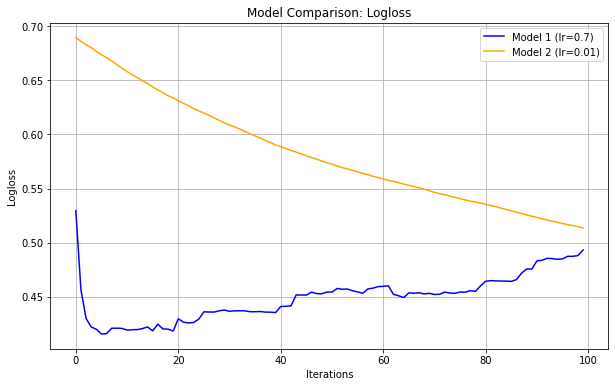

In [35]:
# Get evaluation results
evals1 = model1.get_evals_result()
evals2 = model2.get_evals_result()
from matplotlib import pyplot as plt
# Plotting Logloss for both models
plt.figure(figsize=(10, 6))
plt.plot(evals1['validation']['Logloss'], label='Model 1 (lr=0.7)', color='blue')
plt.plot(evals2['validation']['Logloss'], label='Model 2 (lr=0.01)', color='orange')
plt.title('Model Comparison: Logloss')
plt.xlabel('Iterations')
plt.ylabel('Logloss')
plt.legend()
plt.grid()
plt.show()

## Cross Validation

In [38]:
from catboost import cv
from catboost import Pool
params = {}
params['loss_function'] = 'Logloss'
params['iterations'] = 80
params['custom_loss'] = 'AUC'
params['random_seed'] = 63
params['learning_rate'] = 0.5

cv_data = cv(
    params = params,
    pool = Pool(X_train, label=y_train,cat_features=categorical_features),
    fold_count=5,
    shuffle=True,
    partition_random_seed=0,
    plot=True,
    stratified=True,
    verbose=True
)
cv_data

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/5]
0:	learn: 0.5416583	test: 0.5577983	best: 0.5577983 (0)	total: 19.2ms	remaining: 1.52s
1:	learn: 0.4480584	test: 0.4987980	best: 0.4987980 (1)	total: 69.1ms	remaining: 2.69s
2:	learn: 0.3942972	test: 0.4361650	best: 0.4361650 (2)	total: 116ms	remaining: 2.98s
3:	learn: 0.3828764	test: 0.4276730	best: 0.4276730 (3)	total: 168ms	remaining: 3.19s
4:	learn: 0.3823567	test: 0.4258510	best: 0.4258510 (4)	total: 205ms	remaining: 3.07s
5:	learn: 0.3776789	test: 0.4268510	best: 0.4258510 (4)	total: 256ms	remaining: 3.16s
6:	learn: 0.3698253	test: 0.4201072	best: 0.4201072 (6)	total: 313ms	remaining: 3.26s
7:	learn: 0.3614881	test: 0.4228517	best: 0.4201072 (6)	total: 359ms	remaining: 3.23s
8:	learn: 0.3514458	test: 0.4218028	best: 0.4201072 (6)	total: 400ms	remaining: 3.16s
9:	learn: 0.3410829	test: 0.4227222	best: 0.4201072 (6)	total: 437ms	remaining: 3.06s
10:	learn: 0.3340714	test: 0.4279021	best: 0.4201072 (6)	total: 470ms	remaining: 2.95s
11:	learn: 0.3154790	test: 0

14:	learn: 0.3082920	test: 0.5152241	best: 0.5010526 (2)	total: 777ms	remaining: 3.37s
15:	learn: 0.2991954	test: 0.5143433	best: 0.5010526 (2)	total: 846ms	remaining: 3.38s
16:	learn: 0.2938022	test: 0.5189243	best: 0.5010526 (2)	total: 912ms	remaining: 3.38s
17:	learn: 0.2931351	test: 0.5169446	best: 0.5010526 (2)	total: 1000ms	remaining: 3.44s
18:	learn: 0.2894905	test: 0.5266936	best: 0.5010526 (2)	total: 1.07s	remaining: 3.43s
19:	learn: 0.2847083	test: 0.5267463	best: 0.5010526 (2)	total: 1.14s	remaining: 3.41s
20:	learn: 0.2755032	test: 0.5332122	best: 0.5010526 (2)	total: 1.21s	remaining: 3.4s
21:	learn: 0.2529901	test: 0.5222340	best: 0.5010526 (2)	total: 1.27s	remaining: 3.36s
22:	learn: 0.2457689	test: 0.5212093	best: 0.5010526 (2)	total: 1.33s	remaining: 3.31s
23:	learn: 0.2448345	test: 0.5196784	best: 0.5010526 (2)	total: 1.39s	remaining: 3.25s
24:	learn: 0.2406213	test: 0.5196216	best: 0.5010526 (2)	total: 1.45s	remaining: 3.19s
25:	learn: 0.2363659	test: 0.5232544	best: 

30:	learn: 0.2248986	test: 0.4032560	best: 0.3832927 (6)	total: 2.07s	remaining: 3.27s
31:	learn: 0.2209145	test: 0.4026743	best: 0.3832927 (6)	total: 2.12s	remaining: 3.18s
32:	learn: 0.2104059	test: 0.4096518	best: 0.3832927 (6)	total: 2.21s	remaining: 3.14s
33:	learn: 0.2055373	test: 0.4077837	best: 0.3832927 (6)	total: 2.28s	remaining: 3.08s
34:	learn: 0.1939392	test: 0.4137582	best: 0.3832927 (6)	total: 2.35s	remaining: 3.02s
35:	learn: 0.1910898	test: 0.4261270	best: 0.3832927 (6)	total: 2.42s	remaining: 2.96s
36:	learn: 0.1880266	test: 0.4254803	best: 0.3832927 (6)	total: 2.5s	remaining: 2.9s
37:	learn: 0.1864051	test: 0.4271227	best: 0.3832927 (6)	total: 2.56s	remaining: 2.83s
38:	learn: 0.1811597	test: 0.4309556	best: 0.3832927 (6)	total: 2.64s	remaining: 2.77s
39:	learn: 0.1768492	test: 0.4366899	best: 0.3832927 (6)	total: 2.7s	remaining: 2.7s
40:	learn: 0.1737149	test: 0.4349536	best: 0.3832927 (6)	total: 2.78s	remaining: 2.64s
41:	learn: 0.1734422	test: 0.4347835	best: 0.38

47:	learn: 0.1628880	test: 0.5268377	best: 0.4518137 (2)	total: 2.63s	remaining: 1.75s
48:	learn: 0.1572912	test: 0.5352382	best: 0.4518137 (2)	total: 2.69s	remaining: 1.7s
49:	learn: 0.1564145	test: 0.5370979	best: 0.4518137 (2)	total: 2.75s	remaining: 1.65s
50:	learn: 0.1517180	test: 0.5375426	best: 0.4518137 (2)	total: 2.81s	remaining: 1.6s
51:	learn: 0.1494474	test: 0.5488014	best: 0.4518137 (2)	total: 2.88s	remaining: 1.55s
52:	learn: 0.1448517	test: 0.5591360	best: 0.4518137 (2)	total: 2.94s	remaining: 1.5s
53:	learn: 0.1424829	test: 0.5647505	best: 0.4518137 (2)	total: 3s	remaining: 1.44s
54:	learn: 0.1395570	test: 0.5654754	best: 0.4518137 (2)	total: 3.05s	remaining: 1.39s
55:	learn: 0.1368084	test: 0.5617320	best: 0.4518137 (2)	total: 3.12s	remaining: 1.33s
56:	learn: 0.1341910	test: 0.5669429	best: 0.4518137 (2)	total: 3.17s	remaining: 1.28s
57:	learn: 0.1325513	test: 0.5654808	best: 0.4518137 (2)	total: 3.24s	remaining: 1.23s
58:	learn: 0.1316766	test: 0.5657383	best: 0.4518

62:	learn: 0.1399996	test: 0.5554431	best: 0.4227350 (4)	total: 3.92s	remaining: 1.06s
63:	learn: 0.1373134	test: 0.5570003	best: 0.4227350 (4)	total: 4s	remaining: 1s
64:	learn: 0.1369514	test: 0.5587788	best: 0.4227350 (4)	total: 4.07s	remaining: 939ms
65:	learn: 0.1351006	test: 0.5603454	best: 0.4227350 (4)	total: 4.15s	remaining: 880ms
66:	learn: 0.1334894	test: 0.5599251	best: 0.4227350 (4)	total: 4.4s	remaining: 854ms
67:	learn: 0.1318654	test: 0.5608940	best: 0.4227350 (4)	total: 4.57s	remaining: 806ms
68:	learn: 0.1266980	test: 0.5723855	best: 0.4227350 (4)	total: 4.72s	remaining: 752ms
69:	learn: 0.1254624	test: 0.5727339	best: 0.4227350 (4)	total: 4.92s	remaining: 703ms
70:	learn: 0.1246785	test: 0.5740783	best: 0.4227350 (4)	total: 5.08s	remaining: 644ms
71:	learn: 0.1231154	test: 0.5767946	best: 0.4227350 (4)	total: 5.29s	remaining: 588ms
72:	learn: 0.1189521	test: 0.5918847	best: 0.4227350 (4)	total: 5.44s	remaining: 522ms
73:	learn: 0.1172455	test: 0.5922682	best: 0.42273

,iterations,test-Logloss-mean,test-Logloss-std,train-Logloss-mean,train-Logloss-std,test-AUC-mean,test-AUC-std
0,0,0.545910,0.021813,0.532809,0.026331,0.787497,0.040442
1,1,0.487330,0.028680,0.452536,0.011808,0.814775,0.038342
2,2,0.444423,0.035416,0.403956,0.016845,0.846993,0.027276
3,3,0.444095,0.037294,0.390440,0.008608,0.847569,0.029107
4,4,0.440169,0.041939,0.382923,0.003850,0.847610,0.031392
...,...,...,...,...,...,...,...
75,75,0.551000,0.056666,0.103619,0.009790,0.838868,0.030519
76,76,0.552927,0.055740,0.101811,0.010696,0.837228,0.030221
77,77,0.553415,0.056282,0.100834,0.010435,0.837440,0.029996
78,78,0.552215,0.056314,0.099679,0.010477,0.837524,0.029662


In [39]:
cv_data

,iterations,test-Logloss-mean,test-Logloss-std,train-Logloss-mean,train-Logloss-std,test-AUC-mean,test-AUC-std
0,0,0.545910,0.021813,0.532809,0.026331,0.787497,0.040442
1,1,0.487330,0.028680,0.452536,0.011808,0.814775,0.038342
2,2,0.444423,0.035416,0.403956,0.016845,0.846993,0.027276
3,3,0.444095,0.037294,0.390440,0.008608,0.847569,0.029107
4,4,0.440169,0.041939,0.382923,0.003850,0.847610,0.031392
...,...,...,...,...,...,...,...
75,75,0.551000,0.056666,0.103619,0.009790,0.838868,0.030519
76,76,0.552927,0.055740,0.101811,0.010696,0.837228,0.030221
77,77,0.553415,0.056282,0.100834,0.010435,0.837440,0.029996
78,78,0.552215,0.056314,0.099679,0.010477,0.837524,0.029662


## Roc Curve